<a href="https://colab.research.google.com/github/husthorng/Backpropagation_NN/blob/main/tensorflow_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1141husthorng@gmail.com

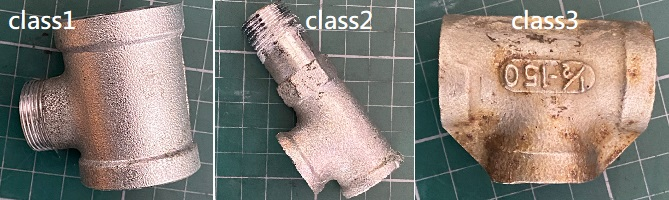

https://chatgpt.com/c/69b91d3e-e680-8321-8e21-5fa867595b1d

In [90]:
#二、安裝套件
!pip install opencv-python
!pip install tensorflow

In [91]:
#三、掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')
import numpy as np

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
#建立資料夾
import os

dataset_path = "/content/drive/MyDrive/AIdataset"

classes = ["class1","class2","class3"]

for c in classes:
    os.makedirs(dataset_path+"/"+c, exist_ok=True)

print("dataset folder ready")

dataset folder ready


In [3]:
#四、WebCam拍照系統
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):

    js = Javascript('''
    async function takePhoto(quality) {

        const div = document.createElement('div');
        const capture = document.createElement('button');

        capture.textContent = 'Capture';

        div.appendChild(capture);

        const video = document.createElement('video');

        video.style.display = 'block';

        const stream = await navigator.mediaDevices.getUserMedia({video:true});

        document.body.appendChild(div);
        div.appendChild(video);

        video.srcObject = stream;

        await video.play();

        google.colab.output.setIframeHeight(document.documentElement.scrollHeight,true);

        await new Promise((resolve)=>capture.onclick=resolve);

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(video,0,0);

        stream.getVideoTracks()[0].stop();

        div.remove();

        return canvas.toDataURL('image/jpeg',quality);

    }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))

    binary = b64decode(data.split(',')[1])

    with open(filename,'wb') as f:
        f.write(binary)

    return filename

In [ ]:
#五、拍照並存入 Dataset
import shutil

label = "take_photo"   # 修改類別

filename = take_photo()

save_path = dataset_path + "/" + label + "/" + filename

shutil.move(filename, save_path)

print("saved:", save_path)

<IPython.core.display.Javascript object>

saved: /content/drive/MyDrive/AIdataset/take_photo/photo.jpg


In [69]:
import os

dataset_path = "/content/drive/MyDrive/AIdataset"
#六、讀取 Dataset
import tensorflow as tf

img_size = 224
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(

    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size,img_size),
    batch_size=batch_size

)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(

    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size,img_size),
    batch_size=batch_size

)

Found 33 files belonging to 3 classes.
Using 27 files for training.
Found 33 files belonging to 3 classes.
Using 6 files for validation.


In [ ]:
val_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
#七、影像正規化
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y:(normalization_layer(x),y))
val_ds = val_ds.map(lambda x,y:(normalization_layer(x),y))

In [92]:
#1 讀取 Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(

    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size,img_size),
    batch_size=batch_size

)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(

    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size,img_size),
    batch_size=batch_size

)

Found 33 files belonging to 3 classes.
Using 27 files for training.
Found 33 files belonging to 3 classes.
Using 6 files for validation.


In [93]:
#2 先保存 class_names
class_names = train_ds.class_names

print(class_names)

['class1', 'class2', 'class3']


In [94]:
#3 再做 normalization
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y:(normalization_layer(x),y))
val_ds = val_ds.map(lambda x,y:(normalization_layer(x),y))

In [95]:
import tensorflow as tf #https://ithelp.ithome.com.tw/m/articles/10233758
from tensorflow.keras import layers, models
#4 建立 CNN
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(256,activation='relu'),

    layers.Dense(len(class_names),activation='softmax')

])


In [96]:
#https://ithelp.ithome.com.tw/m/articles/10233758
#https://chih-sheng-huang821.medium.com/%E5%8D%B7%E7%A9%8D%E7%A5%9E%E7%B6%93%E7%B6%B2%E8%B7%AF-convolutional-neural-network-cnn-1-1%E5%8D%B7%E7%A9%8D%E8%A8%88%E7%AE%97%E5%9C%A8%E5%81%9A%E4%BB%80%E9%BA%BC-7d7ebfe34b8
model.compile(

    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,826,627 (37.49 MB)

 Trainable params: 9,826,627 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:

W=model.weights
np.array(W[1]).shape

(32,)

In [98]:
#九、訓練 AI
epochs = 10

history = model.fit(

    train_ds,
    validation_data=val_ds,
    epochs=epochs

)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 1.0000 - loss: 3.8234e-06 - val_accuracy: 1.0000 - val_loss: 0.0040
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 2.9228e-06 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 1.0000 - loss: 2.2826e-06 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 1.0000 - loss: 1.8014e-06 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 1.0000 - loss: 1.4658e-06 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 1.0000 - loss: 1.2009e-06 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 1.0067e-06 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 1.0000 - loss: 8.5212e-07 - val_accuracy: 1.0000

In [ ]:
#十、儲存模型
model.save("/content/drive/MyDrive/AI_Vision_Model")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=/content/drive/MyDrive/AI_Vision_Model.

In [99]:
model.save("/content/drive/MyDrive/AIdataset/AIdataset_Model.keras")
model.save("/content/drive/MyDrive/AIdataset/AIdataset_ModelC.keras")

In [97]:
#之後讀取模型
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/AIdataset/AIdataset_Model.keras")

In [ ]:
#五、拍照並存入 Dataset
import shutil

label = "take_photo"   # 修改類別

filename = take_photo()

save_path = dataset_path + "/" + label + "/" + filename

shutil.move(filename, save_path)

print("saved:", save_path)

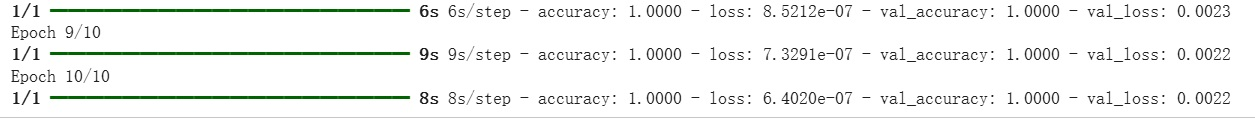

In [101]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# 載入模型
model = load_model("/content/drive/MyDrive/AIdataset/AIdataset_ModelC.keras")

# class names（一定要跟訓練一致）
class_names = ['class1','class2','class3']  # ⚠️請改成你的

# 讀圖
img = cv2.imread("/content/drive/MyDrive/AIdataset/class3/IMG_0074.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # 🔥關鍵

img = cv2.resize(img,(224,224))
img = img / 255.0
img = np.expand_dims(img,0)

# 預測
pred = model.predict(img)
pred_class = np.argmax(pred)

print("prediction:", pred)
print("預測類別:", class_names[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
prediction: [[1.2490475e-10 6.6678640e-06 9.9999332e-01]]
預測類別: class3


In [ ]:
pred[0][0]

np.float32(1.8066378e-10)

In [ ]:
save_path

'/content/drive/MyDrive/AI_Vision_Dataset/class1/photo.jpg'